# Employee Salary Prediction & Analysis

**Goal:** Predict employee salary using Age, Gender, Department, Job Title, Experience, Education Level, and Location.

## Workflow
Data → EDA → Missing values → Outliers → Train/Test Split → Encoding → Linear Regression → Random Forest → Evaluation → Cross-Validation → Model Selection → Pipeline → Joblib → New Employee Prediction


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

## 1. Load the dataset

In [7]:
df = pd.read_csv("employers_data.csv")
print(df.shape)
df.head()

(10000, 10)


,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


## 2. Understand the data

We inspect data types, columns, and summary statistics before modeling.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Name,10000,9868,James Smith,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,35.4559,10.000213,21.0,27.0,34.0,43.0,60.0
Gender,10000,2,Male,5108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,10000,6,Product,1724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Title,10000,5,Manager,3325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience_Years,10000.0,NaN,NaN,NaN,12.3709,9.148951,0.0,5.0,10.0,19.0,37.0
Education_Level,10000,3,Master,4930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,10000,5,Austin,2034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,10000.0,NaN,NaN,NaN,115381.5,46066.139047,25000.0,70000.0,120000.0,150000.0,215000.0


In [10]:
print(df.columns.tolist())

['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years', 'Education_Level', 'Location', 'Salary']


## 3. Missing values

Never assume a dataset is complete. First check missing values.

Typical solutions:
- Numerical → median/mean imputation
- Categorical → mode or `"Unknown"`
- Too many missing values → consider dropping the column
- Rows with excessive missing data → consider removing the row

In [11]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


## 4. Duplicate rows

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


If duplicates are accidental, use `df.drop_duplicates()`. Do not blindly delete repeated rows when repeated observations are legitimate.

## 5. Explore Salary

count     10000.000000
mean     115381.500000
std       46066.139047
min       25000.000000
25%       70000.000000
50%      120000.000000
75%      150000.000000
max      215000.000000
Name: Salary, dtype: float64


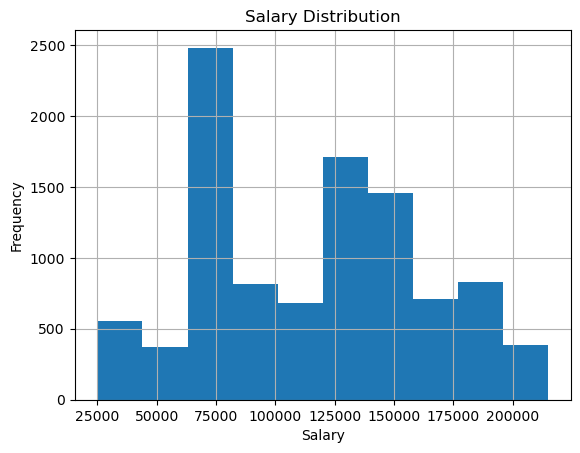

In [20]:
import seaborn as sns
print(df["Salary"].describe())

df["Salary"].hist()
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution")
plt.show()



## 6. Explore categorical columns

In [21]:
categorical_columns = ["Gender", "Department", "Job_Title", "Education_Level", "Location"]

for col in categorical_columns:
    
    print("\n",df[col].value_counts())


 Gender
Male      5108
Female    4892
Name: count, dtype: int64

 Department
Product        1724
Engineering    1683
Sales          1669
Marketing      1669
HR             1660
Finance        1595
Name: count, dtype: int64

 Job_Title
Manager      3325
Analyst      2799
Executive    1921
Engineer     1375
Intern        580
Name: count, dtype: int64

 Education_Level
Master      4930
Bachelor    3381
PhD         1689
Name: count, dtype: int64

 Location
Austin           2034
Seattle          2017
Chicago          2008
New York         1980
San Francisco    1961
Name: count, dtype: int64


## 7. Salary by Education Level

In [22]:
df.groupby("Education_Level")["Salary"].agg(["count","mean","median","min","max"]).sort_values("mean")

,count,mean,median,min,max
Education_Level,,,,,
Bachelor,3381,69529.724933,70000.0,25000,125000
Master,4930,134234.279919,135000.0,55000,215000
PhD,1689,152137.359384,150000.0,85000,210000


## 8. Salary by Job Title

In [23]:
df.groupby("Job_Title")["Salary"].agg(["count","mean","median","min","max"]).sort_values("mean")

,count,mean,median,min,max
Job_Title,,,,,
Intern,580,35801.724138,35000.0,25000,50000
Analyst,2799,69478.385138,70000.0,50000,85000
Engineer,1375,99272.727273,100000.0,70000,125000
Manager,3325,135260.150376,135000.0,105000,165000
Executive,1921,183414.888079,185000.0,150000,215000


## 9. Salary outliers using IQR

IQR = Q3 - Q1

Lower bound = Q1 - 1.5 × IQR  
Upper bound = Q3 + 1.5 × IQR

An IQR outlier is only a **potential** outlier. A high salary may be a valid Executive salary, so we should not automatically delete it.

In [24]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower_Bound =", lower_bound)
print("Upper_Bound =", upper_bound)

outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
print("Potential outliers:", len(outliers))

Q1 = 70000.0
Q3 = 150000.0
IQR = 80000.0
Lower_Bound = -50000.0
Upper_Bound = 270000.0
Potential outliers: 0


In [25]:
outliers["Salary"]


Series([], Name: Salary, dtype: int64)

## 10. Separate features and target

`Salary` is the target `y`; all other columns are features `X`.

In [26]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

print(X.shape)
print(y.shape)

(10000, 9)
(10000,)


## 11. Train/Test Split

80% is used for training and 20% for testing.

The test set represents unseen data.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 9)
X_test : (2000, 9)
y_train: (8000,)
y_test : (2000,)


## 12. future preprocessing

Numerical:
- Age
- Experience_Years

Categorical:
- Gender
- Department
- Job_Title
- Education_Level
- Location

In [28]:
numerical_features = ["Age", "Experience_Years"]
categorical_features = ["Gender", "Department", "Job_Title", "Education_Level", "Location"]

## 13. One-Hot Encoding

- I used One-Hot Encoding for categorical variables because it prevents the model from assuming any false numerical order between categories.
   
- Although Education has an order, I used One-Hot Encoding in Linear Regression because I don't want the model to assume a simple 0-to-1-to-2 relationship between education levels and salary.

- I also used handle_unknown='ignore' so the model can safely handle new categories during prediction

In [29]:
preprocessor = ColumnTransformer([
    ("num", "passthrough", numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

## 14. Linear Regression

In [30]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

## 15. Evaluate Linear Regression

I used MAE, MSE, RMSE and R². 
- MAE tells me the average prediction error in salary units. 
- MSE gives more importance to large errors.
- RMSE is the square root of MSE, so it is easier to interpret because it is in the same unit as salary.
- R² tells me how much variation in salary is explained by my model

In [31]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression MAE :", linear_mae)
print("Linear Regression MSE :", linear_mse)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²  :", linear_r2)

Linear Regression MAE : 3337.937758036401
Linear Regression MSE : 17375021.62159713
Linear Regression RMSE: 4168.335593686901
Linear Regression R²  : 0.9917562580370475


## 16. Random Forest Regressor

Random Forest can learn nonlinear patterns, so we use it as a comparison model. We choose models based on measured performance, not because one model is more advanced.

In [32]:
rf_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])),
    ("regressor", RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE :", rf_mae)
print("Random Forest MSE :", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²  :", rf_r2)

Random Forest MAE : 3897.4177836125864
Random Forest MSE : 24019702.662603922
Random Forest RMSE: 4900.989967608985
Random Forest R²  : 0.9886036267988741


## 17. Compare models

In [33]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "MSE": [linear_mse, rf_mse],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})
comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,3337.937758,1.737502e+07,4168.335594,0.991756
1,Random Forest,3897.417784,2.401970e+07,4900.989968,0.988604


### Model selection

In our earlier experiment, Linear Regression gave approximately MAE 3337, RMSE 4168, and R² 0.9918, while Random Forest gave approximately MAE 3897, RMSE 4901, and R² 0.9886.

The clean final One-Hot version is evaluated again above. We select the model with the better test and cross-validation performance.

## 18. 5-Fold Cross-Validation

In [36]:
cv_lr = cross_val_score(linear_model, X_train, y_train, cv=5, scoring="r2")
print("Linear Regression CV R²:", cv_lr)
print("Mean CV R²:", cv_lr.mean())
print("Std CV R² :", cv_lr.std())

Linear Regression CV R²: [0.99135673 0.99149482 0.99153373 0.99123553 0.99099539]
Mean CV R²: 0.9913232403434581
Std CV R² : 0.00019495674557046608


In [37]:
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="r2")
print("Random Forest CV R²:", cv_rf)
print("Mean CV R²:", cv_rf.mean())
print("Std CV R² :", cv_rf.std())

Random Forest CV R²: [0.98941987 0.98863866 0.9883887  0.98855407 0.98845646]
Mean CV R²: 0.988691549994171
Std CV R² : 0.00037393558758898516


Cross-validation checks whether performance is consistent across different validation folds.

Higher mean R² is better. Lower standard deviation generally means more consistent performance.

### Final Pipeline

We combine preprocessing and Linear Regression into one Pipeline.

This means a Streamlit user can provide raw employee values; the Pipeline performs the same encoding automatically before prediction.

In [34]:
final_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])),
    ("regressor", LinearRegression())
])

final_pipeline.fit(X_train, y_train)

final_pred = final_pipeline.predict(X_test)

print("Final Model MAE :", mean_absolute_error(y_test, final_pred))
print("Final Model MSE :", mean_squared_error(y_test, final_pred))
print("Final Model RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))
print("Final Model R²  :", r2_score(y_test, final_pred))

Final Model MAE : 3337.937758036401
Final Model MSE : 17375021.62159713
Final Model RMSE: 4168.335593686901
Final Model R²  : 0.9917562580370475


# 19. Model Validation 
A high R² score is a good sign, but it does not guarantee that the model is perfect. Therefore, we perform additional checks to make sure the model is reliable and its predictions are reasonable.

We will check:
- Train R² vs Test R²
- Cross-validation consistency
- Data leakage risk
- Actual vs Predicted Salary
- Residuals
- Prediction errors

> A high R² is more trustworthy when the model also performs well on unseen data, gives similar results in cross-validation, and has small and reasonable errors.”

### Train R² vs Test R²

We compare performance on training data and unseen test data. If training performance is extremely high but test performance is much lower, the model may be overfitting.

In [39]:
train_pred = final_pipeline.predict(X_train)
test_pred = final_pipeline.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)
print("R² Difference:", abs(train_r2 - test_r2))

Train R²: 0.9913889619225543
Test R² : 0.9917562580370475
R² Difference: 0.00036729611449315414


### Data Leackage Check
Data leakage happens when information that should not be available to the model during training is accidentally used to make predictions.

    In this project:
- Salary is separated as the target variable.
- The training and test sets do not overlap.
- The test set is not used to fit the model.
- One-Hot Encoding is inside the Pipeline, so preprocessing is fitted as part of the training process.
- Employee_ID and Name are not used as predictive features because they identify records rather than describe salary-related characteristics.

In [46]:
print("Target column:", "Salary")
print("Salary present in X columns?", "Salary" in X.columns)

train_indices = set(X_train.index)
test_indices = set(X_test.index)
print("Train/Test index overlap:", len(train_indices.intersection(test_indices)))

print("Model features:", list(X.columns))

Target column: Salary
Salary present in X columns? False
Train/Test index overlap: 0
Model features: ['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years', 'Education_Level', 'Location']


### Cross-Validation

A single train-test split can sometimes give a favorable or unfavorable result. Therefore, I use 5-fold cross-validation on the training data.

The model is trained and validated five times using different validation folds. I look at the mean R² and standard deviation.

- Higher mean R² is better.
- Lower standard deviation generally means more consistent performance across folds.

In [50]:
cv_lr = cross_val_score(linear_model, X_train, y_train, cv=5, scoring="r2")
print("Linear Regression CV R²:", cv_lr)
print(f"Mean CV R²:, {cv_lr.mean():.6f}")
print(f"Std CV R² :, {cv_lr.std():.6f}")

Linear Regression CV R²: [0.99135673 0.99149482 0.99153373 0.99123553 0.99099539]
Mean CV R²:, 0.991323
Std CV R² :, 0.000195


### Actual vs Predicted Salary

This graph helps us compare predicted salaries with actual salaries.Points closer to the diagonal reference line indicate more accurate predictions.

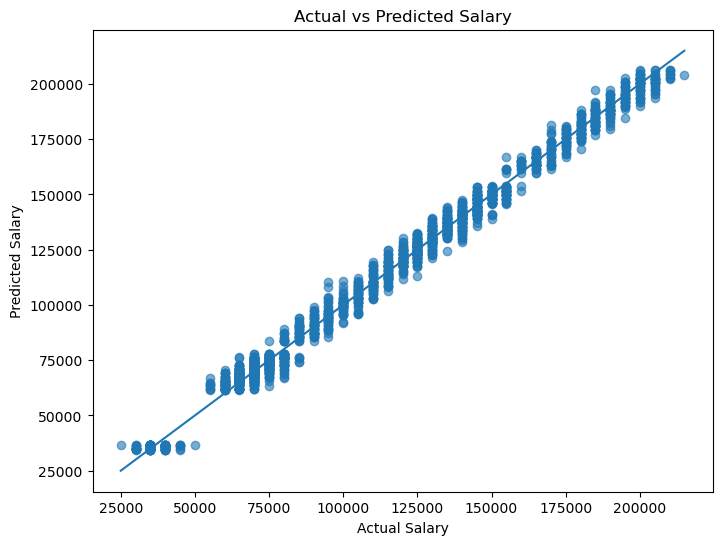

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_pred, alpha=0.6)

min_value = min(y_test.min(), test_pred.min())
max_value = max(y_test.max(), test_pred.max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

### Residual Analysis

Residual= Actual Salary - Predicted Salary

I check whether residuals are reasonably scattered around zero. A strong visible pattern can indicate that the model is missing some relationship in the data.

A good residual plot should have the errors spread around zero without any clear pattern.

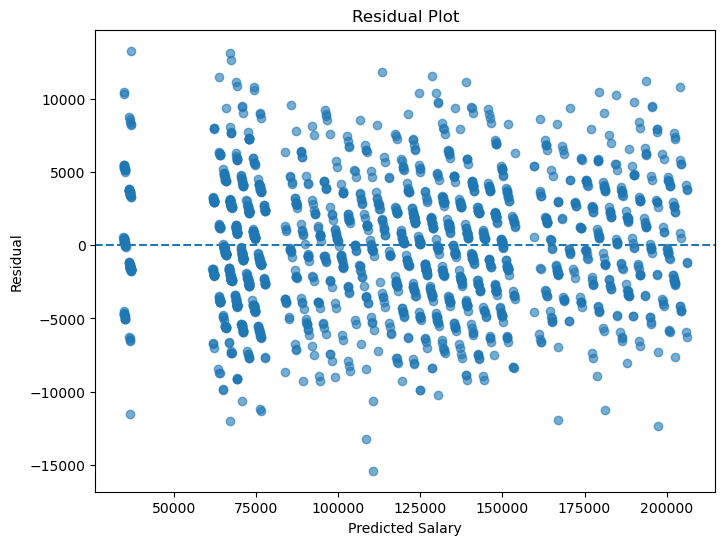

Mean residual: -30.472795855172468
Residual standard deviation: 4169.266652844495


In [51]:
residuals = y_test - test_pred

plt.figure(figsize=(8, 6))
plt.scatter(test_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Salary")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

print("Mean residual:", residuals.mean())
print("Residual standard deviation:", residuals.std())

### Prediction Error Analysis

I don’t only look at the R² score. I also check the errors of individual predictions. MAE tells me, on average, how far my predictions are from the actual salary. I also look at the biggest errors to find predictions where the model performed poorly and may need further investigation

In [44]:
error_df = pd.DataFrame({
    "Actual_Salary": y_test.values,
    "Predicted_Salary": test_pred,
    "Absolute_Error": np.abs(y_test.values - test_pred),
    "Residual": y_test.values - test_pred
})

print("Mean Absolute Error:", error_df["Absolute_Error"].mean())
print("Median Absolute Error:", error_df["Absolute_Error"].median())
print("Maximum Absolute Error:", error_df["Absolute_Error"].max())

error_df.sort_values("Absolute_Error", ascending=False).head(10)

Mean Absolute Error: 3337.937758036401
Median Absolute Error: 2770.8862768696563
Maximum Absolute Error: 15412.355578972274


,Actual_Salary,Predicted_Salary,Absolute_Error,Residual
1893,95000,110412.355579,15412.355579,-15412.355579
890,50000,36702.692811,13297.307189,13297.307189
267,95000,108258.465858,13258.465858,-13258.465858
1576,80000,66877.706092,13122.293908,13122.293908
82,80000,67358.574891,12641.425109,12641.425109
1568,185000,197354.850744,12354.850744,-12354.850744
1474,55000,66991.892110,11991.892110,-11991.892110
1915,155000,166933.525213,11933.525213,-11933.525213
509,125000,113177.954229,11822.045771,11822.045771
1867,140000,128400.038022,11599.961978,11599.961978


### Validation Conclusion

I do not judge my model only by looking at the R² score. I also check the difference between training and testing R², cross-validation results, MAE, RMSE, actual vs predicted values, residuals, prediction errors, and possible data leakage.

My test R² is around 0.99, which is unusually high. So, I need to check whether this result is genuine. If cross-validation gives similar results, the difference between train and test R² is small, the residuals look reasonable, and there is no data leakage, then I can have more confidence in the model.

I would not say that my model is "99% accurate." R² does not mean accuracy percentage. It tells us how much of the variation in salary is explained by the model. The model should also be tested on new, real-world data to see how well it performs.

## 19. Interpret Linear Regression coefficients

Coefficients show the direction and size of the relationship learned by Linear Regression.

A positive coefficient contributes positively to the prediction relative to the reference representation; a negative coefficient contributes negatively.

Do not treat coefficient magnitude as a universal feature-importance ranking because features have different scales and categorical variables are encoded into separate columns.

In [52]:
coef_preprocessor = ColumnTransformer([
    ("num", "passthrough", numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

coef_pipeline = Pipeline([
    ("preprocessor", coef_preprocessor),
    ("regressor", LinearRegression())
])

coef_pipeline.fit(X_train, y_train)

feature_names = coef_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = coef_pipeline.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values("Absolute_Coefficient", ascending=False).head(15)

,Feature,Coefficient,Absolute_Coefficient
12,cat__Job_Title_Executive,53270.444896,53270.444896
13,cat__Job_Title_Intern,-47795.792423,47795.792423
10,cat__Job_Title_Analyst,-21820.565920,21820.565920
14,cat__Job_Title_Manager,18310.804561,18310.804561
15,cat__Education_Level_Bachelor,-4655.154165,4655.154165
17,cat__Education_Level_PhD,4617.439646,4617.439646
11,cat__Job_Title_Engineer,-1964.891113,1964.891113
1,num__Experience_Years,1664.612002,1664.612002
4,cat__Department_Engineering,324.703506,324.703506
6,cat__Department_HR,-298.338468,298.338468


## 20. Save the complete model

In [53]:
joblib.dump(final_pipeline, "employee_salary_model.pkl")
print("Saved: employee_salary_model.pkl")

Saved: employee_salary_model.pkl


## 21. Load the saved model

In [54]:
loaded_model = joblib.load("employee_salary_model.pkl")
print("Model loaded successfully.")

Model loaded successfully.


## 22. Predict salary for a new employee

In [55]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Gender": ["Female"],
    "Department": ["Engineering"],
    "Job_Title": ["Engineer"],
    "Experience_Years": [5],
    "Education_Level": ["Master"],
    "Location": ["Austin"]
})

predicted_salary = loaded_model.predict(new_employee)
print(f"Predicted Salary: {predicted_salary[0]:,.2f}")

Predicted Salary: 94,428.97
